# 260413-3: Deep Networks — Challenges and Solutions

네트워크를 **깊게** 쌓으면 더 복잡한 패턴을 학습할 수 있지만, 동시에 새로운 문제들이 발생합니다.
이번 실습에서는 깊은 네트워크에서 관찰되는 학습상의 문제들을 실험으로 확인하고, 이를 완화하는 기법들을 살펴봅니다.
특히 **activation 분포**와 **gradient 흐름**을 시각화하여 문제의 원인을 눈으로 확인합니다.

## 학습 목표
- 네트워크 깊이에 따른 학습 양상의 차이를 **activation/gradient 시각화**로 관찰하기
- **Weight Initialization** (Xavier, Kaiming)이 activation 분포에 미치는 영향 이해하기
- **Batch Normalization**이 Internal Covariate Shift를 해결하는 원리 파악하기
- 모든 기법을 조합하여 최적의 FC 모델 설계하기

## 구성
1. Depth Experiment — 깊이에 따른 학습 난이도 + activation/gradient 시각화
2. Weight Initialization — 초기화 방법별 비교 + 가중치 분포 시각화
3. Batch Normalization — Internal Covariate Shift 해결 + activation 분포 비교
4. Summary Comparison — 전체 실험 결과 종합
5. Best Model Challenge — 모든 기법 조합하여 최고 성능 달성

### Recap: Vanishing Gradient Problem

앞서 다룬 핵심 개념을 정리합니다.

#### 왜 깊은 네트워크는 학습이 어려울까?

Backpropagation에서 gradient는 **chain rule**을 따라 출력층에서 입력층으로 전파됩니다.
각 레이어를 지날 때마다 gradient에 해당 레이어의 가중치와 activation function의 미분값이 **곱해집니다**.

$$\frac{\partial L}{\partial W_1} = \frac{\partial L}{\partial h_n} \cdot \frac{\partial h_n}{\partial h_{n-1}} \cdot \ldots \cdot \frac{\partial h_2}{\partial h_1} \cdot \frac{\partial h_1}{\partial W_1}$$

| 문제 | 원인 | 증상 |
|------|------|------|
| **Vanishing Gradient** | 각 레이어의 gradient 곱이 < 1 | 앞쪽 레이어 가중치가 거의 업데이트되지 않음 |
| **Exploding Gradient** | 각 레이어의 gradient 곱이 > 1 | Loss가 NaN/Inf로 발산 |
| **Internal Covariate Shift** | 앞쪽 레이어 변화 → 뒤쪽 입력 분포 변화 | 학습이 불안정하고 느려짐 |

> Day 1에서 **ReLU**로 vanishing gradient를 완화했지만, 네트워크가 충분히 깊어지면 ReLU만으로는 부족합니다.
> 이번 실습에서는 **초기화(Initialization)**와 **Batch Normalization**이 왜 필요한지 activation 분포와 gradient 흐름을 직접 관찰합니다.

#### 핵심 아이디어
```
Shallow (3-layer):  gradient가 몇 번만 곱해짐 → 비교적 안정
Deep (7-layer):     gradient가 여러 번 곱해짐 → 앞쪽 레이어에서 소실/폭발 가능
```

In [1]:
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    import subprocess
    gpu_info = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    if gpu_info.returncode == 0:
        print('GPU available:')
        print(gpu_info.stdout.split('\n')[8])
    else:
        print('No GPU detected. Go to Runtime > Change runtime type > GPU')

GPU available:
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print('Using device:', device)

# --- CIFAR-10 ---
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_set, val_set = torch.utils.data.random_split(
    trainset, [45000, 5000],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_set, batch_size=256, shuffle=True)
val_loader = DataLoader(val_set, batch_size=256, shuffle=False)
test_loader = DataLoader(testset, batch_size=256, shuffle=False)

print(f'Train: {len(train_set)}, Val: {len(val_set)}, Test: {len(testset)}')

# --- Utility Functions ---

def build_mlp(hidden_dims, input_dim=3*32*32, num_classes=10):
    """hidden_dims 리스트를 받아 nn.Sequential MLP를 생성합니다."""
    layers = [nn.Flatten()]
    in_dim = input_dim
    for h in hidden_dims:
        layers.append(nn.Linear(in_dim, h))
        layers.append(nn.ReLU())
        in_dim = h
    layers.append(nn.Linear(in_dim, num_classes))
    return nn.Sequential(*layers)

@torch.no_grad()
def check_accuracy(loader, model):
    """모델의 정확도를 계산합니다."""
    model.eval()
    num_correct = 0
    num_samples = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        scores = model(x)
        _, preds = scores.max(1)
        num_correct += (preds == y).sum().item()
        num_samples += preds.size(0)
    return num_correct / num_samples

def train_model(model, optimizer, train_loader, val_loader, epochs=10, verbose=True):
    """모델을 학습하고 히스토리를 반환합니다."""
    model = model.to(device)
    history = {'train_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        num_batches = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            scores = model(x)
            loss = F.cross_entropy(scores, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            num_batches += 1

        avg_loss = running_loss / num_batches
        train_acc = check_accuracy(train_loader, model)
        val_acc = check_accuracy(val_loader, model)
        history['train_loss'].append(avg_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if verbose:
            print(f'Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | '
                  f'Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}')
    return history

def plot_history(history, title='Training History'):
    """학습 히스토리를 시각화합니다."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history['train_loss'], 'b-o', label='Train Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{title} - Loss')
    axes[0].legend()
    axes[0].grid(True)
    axes[1].plot(history['train_acc'], 'b-o', label='Train Acc')
    axes[1].plot(history['val_acc'], 'r-o', label='Val Acc')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'{title} - Accuracy')
    axes[1].legend()
    axes[1].grid(True)
    plt.tight_layout()
    plt.show()

print('Utilities loaded.')

Using device: cuda


100%|██████████| 170M/170M [00:06<00:00, 28.1MB/s]


Train: 45000, Val: 5000, Test: 10000
Utilities loaded.


## 1. Depth Experiment — Why Deeper $\neq$ Better (Without Tricks)

같은 hidden 크기(256)를 사용하되, **깊이만 다르게** 하여 학습 결과를 비교합니다.
단순히 loss/accuracy만 보는 것이 아니라, 각 레이어의 **activation 분포**와 **gradient 크기**를
시각화하여 **왜** 깊은 네트워크가 어려운지 직접 확인합니다.

In [3]:
# 깊이별 실험: SGD를 사용해 init/depth의 영향이 잘 드러나도록 함
depth_configs = {
    '3-layer': [256, 256],
    '10-layer': [256] * 9,
    '20-layer': [256] * 19,
}

depth_results = {}
depth_models = {}  # activation/gradient 시각화를 위해 저장

############################################################################
# TODO 1: 각 depth config에 대해 모델을 생성하고 학습하세요 (~6줄)               #
# - build_mlp로 모델 생성                                                   #
# - kaiming 초기화 적용 (init_weights는 다음 섹션에서 정의됨 — 우선 inline으로)   #
# - SGD optimizer (lr=0.05, momentum=0.9) 사용                             #
# - 6 epoch 학습                                                            #
# Hint: for문으로 depth_configs를 순회하며 train_model 호출                    #
############################################################################
for name, hidden_dims in depth_configs.items():
    print(f'\n=== {name} (hidden: {hidden_dims}) ===')
    torch.manual_seed(42)
    model = build_mlp(hidden_dims)
    # quick inline kaiming init (init_weights 함수는 다음 섹션에서 다시 정의)
    for m in model.modules():
        if isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            nn.init.zeros_(m.bias)
    optimizer = optim.SGD(model.parameters(), lr=0.05, momentum=0.9)
    history = train_model(model, optimizer, train_loader, val_loader, epochs=6)
    depth_results[name] = history
    depth_models[name] = model
#                             END OF YOUR CODE                             #
############################################################################



=== 3-layer (hidden: [256, 256]) ===
Epoch 1/6 | Loss: 1.8076 | Train Acc: 0.4480 | Val Acc: 0.4292
Epoch 2/6 | Loss: 1.5404 | Train Acc: 0.4931 | Val Acc: 0.4454
Epoch 3/6 | Loss: 1.4338 | Train Acc: 0.5300 | Val Acc: 0.4630
Epoch 4/6 | Loss: 1.3496 | Train Acc: 0.5592 | Val Acc: 0.4678
Epoch 5/6 | Loss: 1.2797 | Train Acc: 0.5746 | Val Acc: 0.4820
Epoch 6/6 | Loss: 1.2235 | Train Acc: 0.5983 | Val Acc: 0.4908

=== 10-layer (hidden: [256, 256, 256, 256, 256, 256, 256, 256, 256]) ===
Epoch 1/6 | Loss: 1.8702 | Train Acc: 0.3978 | Val Acc: 0.3846
Epoch 2/6 | Loss: 1.6153 | Train Acc: 0.4636 | Val Acc: 0.4418
Epoch 3/6 | Loss: 1.5111 | Train Acc: 0.4968 | Val Acc: 0.4554
Epoch 4/6 | Loss: 1.4168 | Train Acc: 0.5260 | Val Acc: 0.4742
Epoch 5/6 | Loss: 1.3578 | Train Acc: 0.5316 | Val Acc: 0.4652
Epoch 6/6 | Loss: 1.3064 | Train Acc: 0.5666 | Val Acc: 0.4914

=== 20-layer (hidden: [256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256]) ===
Epoch 1/

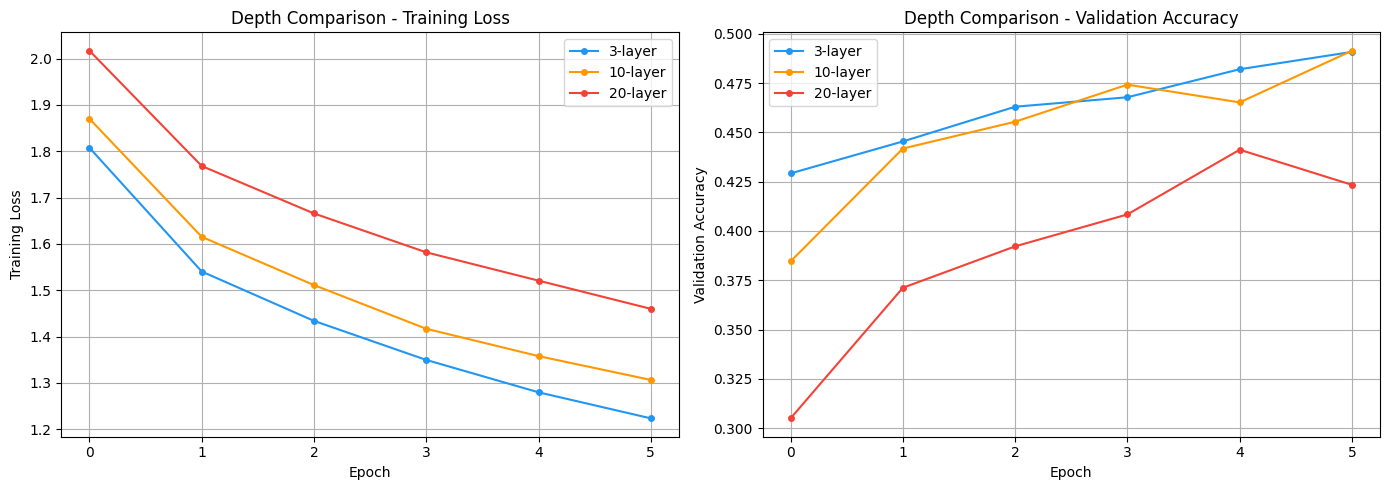

3-layer: Best val acc = 0.4908
10-layer: Best val acc = 0.4914
20-layer: Best val acc = 0.4412


In [4]:
# 깊이별 Loss / Accuracy 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2196F3', '#FF9800', '#F44336']

for (name, hist), color in zip(depth_results.items(), colors):
    axes[0].plot(hist['train_loss'], '-o', label=name, color=color, markersize=4)
    axes[1].plot(hist['val_acc'], '-o', label=name, color=color, markersize=4)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Loss')
axes[0].set_title('Depth Comparison - Training Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Depth Comparison - Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

for name, hist in depth_results.items():
    print(f'{name}: Best val acc = {max(hist["val_acc"]):.4f}')

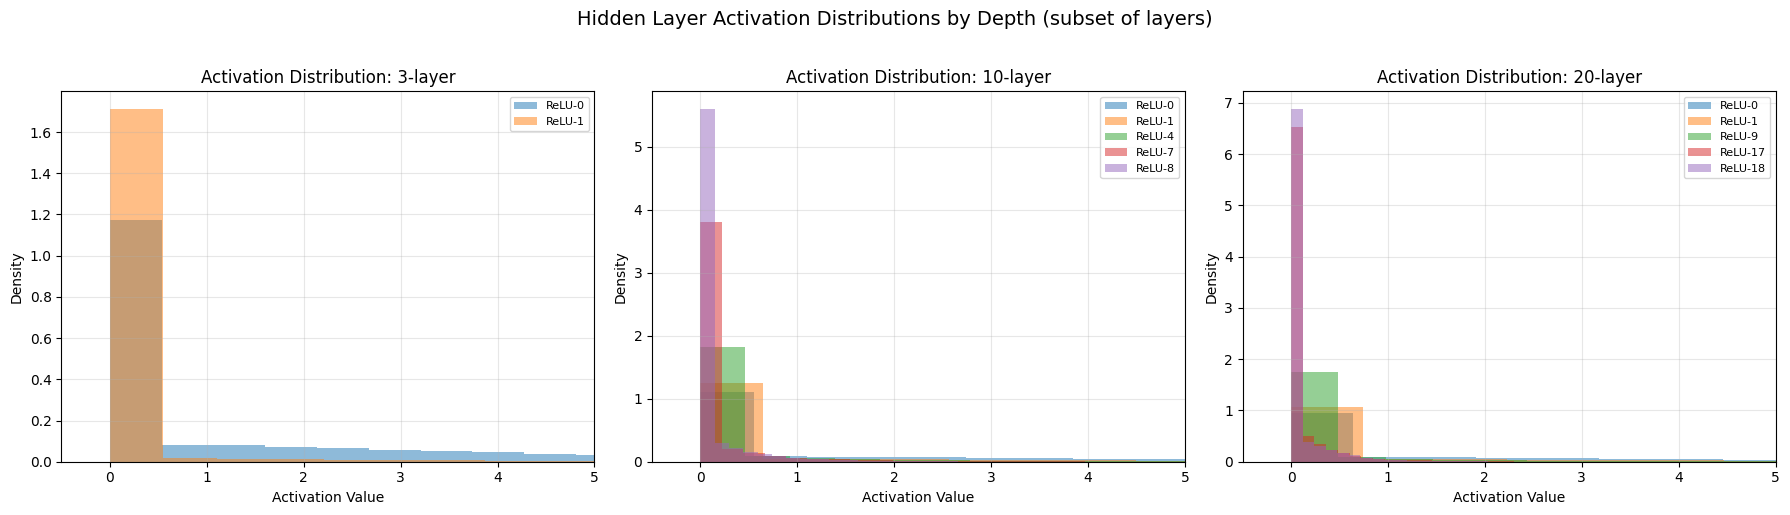

Observation (this run): in deeper networks, activations in later layers may collapse
toward 0 or concentrate in narrow ranges, which limits how much each layer can represent.


In [5]:
# Activation 분포 시각화: 각 depth별로 hidden layer의 activation 히스토그램
# Hook을 사용하여 각 ReLU의 출력값을 수집합니다.

def collect_activations(model, data_loader, max_batches=5):
    """모델의 각 ReLU 출력을 수집합니다."""
    activations = {}
    hooks = []

    def make_hook(name):
        def hook_fn(module, input, output):
            if name not in activations:
                activations[name] = []
            activations[name].append(output.detach().cpu().numpy().flatten())
        return hook_fn

    relu_idx = 0
    for module in model.modules():
        if isinstance(module, nn.ReLU):
            hooks.append(module.register_forward_hook(make_hook(f'ReLU-{relu_idx}')))
            relu_idx += 1

    model.eval()
    with torch.no_grad():
        for i, (x, y) in enumerate(data_loader):
            if i >= max_batches:
                break
            x = x.to(device)
            model(x)

    for h in hooks:
        h.remove()

    for name in activations:
        activations[name] = np.concatenate(activations[name])
    return activations


def subsample_layers(act_dict, k=5):
    items = list(act_dict.items())
    if len(items) <= k:
        return items
    n = len(items)
    picks = [0, 1, n // 2, n - 2, n - 1]
    return [items[i] for i in picks]


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(depth_models.items()):
    ax = axes[idx]
    acts = collect_activations(model, val_loader, max_batches=2)
    for layer_name, values in subsample_layers(acts):
        ax.hist(values, bins=50, alpha=0.5, density=True, label=layer_name)
    ax.set_title(f'Activation Distribution: {name}')
    ax.set_xlabel('Activation Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.set_xlim(-0.5, 5)
    ax.grid(True, alpha=0.3)

plt.suptitle('Hidden Layer Activation Distributions by Depth (subset of layers)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('Observation (this run): in deeper networks, activations in later layers may collapse')
print('toward 0 or concentrate in narrow ranges, which limits how much each layer can represent.')


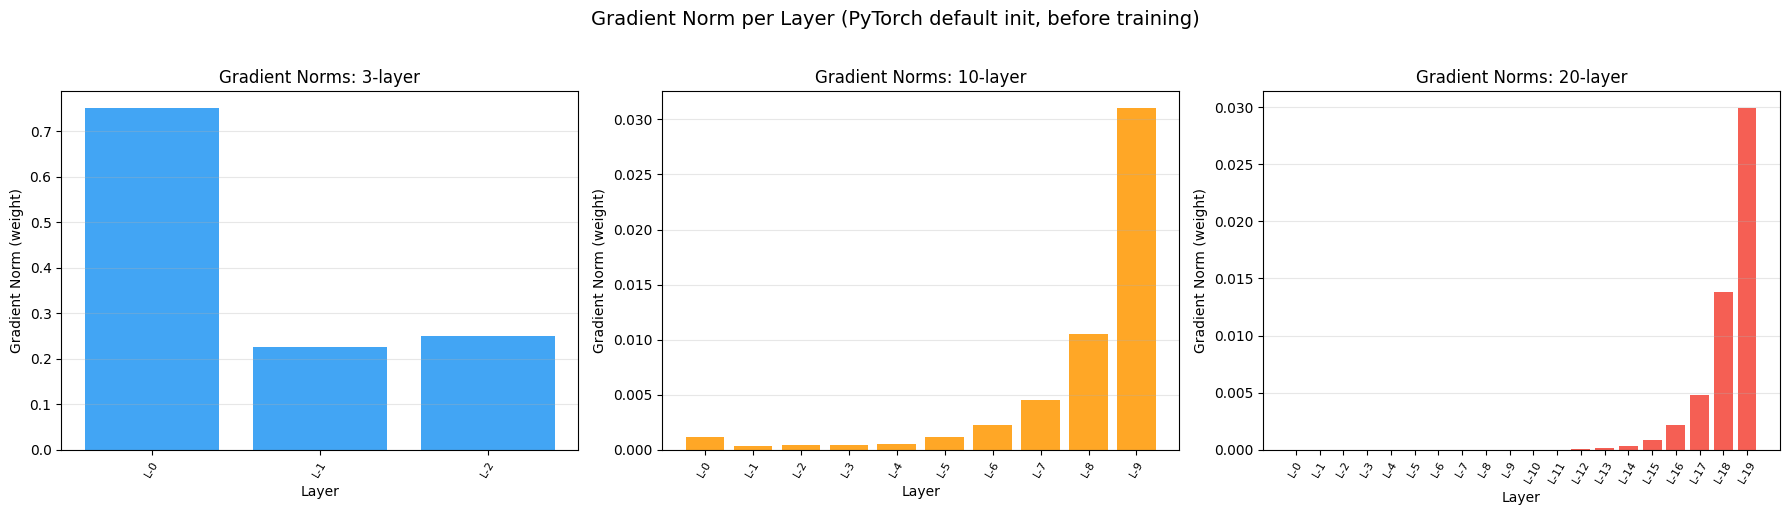

Observation (this run): in deeper networks, the gradient norms across layers are
not all equal — earlier layers can receive smaller gradients than later layers,
which is one face of the vanishing gradient phenomenon.


In [6]:
# Gradient Norm per Layer: 깊은 네트워크에서 gradient가 어떻게 변하는지 시각화
# 한 배치에 대해 backward를 수행한 뒤, 각 Linear layer의 weight gradient norm을 측정합니다.

def measure_gradient_norms(model, data_loader):
    """각 Linear 레이어의 gradient norm을 측정합니다."""
    model.train()
    model.to(device)
    x, y = next(iter(data_loader))
    x, y = x.to(device), y.to(device)

    model.zero_grad()
    scores = model(x)
    loss = F.cross_entropy(scores, y)
    loss.backward()

    grad_norms = []
    layer_names = []
    idx = 0
    for module in model.modules():
        if isinstance(module, nn.Linear):
            grad_norm = module.weight.grad.norm().item()
            grad_norms.append(grad_norm)
            layer_names.append(f'L-{idx}')
            idx += 1
    return layer_names, grad_norms

# 각 depth별로 gradient norm 측정 및 비교
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
palette = ['#2196F3', '#FF9800', '#F44336']

for ax_idx, ((name, hidden_dims), color) in enumerate(zip(depth_configs.items(), palette)):
    ax = axes[ax_idx]
    # 새로 초기화한 모델로 측정 (학습 전 초기 상태에서의 gradient 흐름)
    torch.manual_seed(42)
    fresh_model = build_mlp(hidden_dims)
    layer_names, grad_norms = measure_gradient_norms(fresh_model, train_loader)

    bars = ax.bar(layer_names, grad_norms, color=color, alpha=0.85)
    ax.set_title(f'Gradient Norms: {name}')
    ax.set_xlabel('Layer')
    ax.set_ylabel('Gradient Norm (weight)')
    ax.tick_params(axis='x', labelrotation=60, labelsize=8)
    ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('Gradient Norm per Layer (PyTorch default init, before training)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('Observation (this run): in deeper networks, the gradient norms across layers are')
print('not all equal — earlier layers can receive smaller gradients than later layers,')
print('which is one face of the vanishing gradient phenomenon.')


> **관찰**: 이 실험 설정에서는 네트워크를 20-layer로 깊게 만들었을 때 더 얕은 모델보다 오히려 val accuracy가 낮거나 훈련이 불안정해지는 경향이 이 실험에서 관찰됩니다.
> 표현력이 더 높음에도 학습이 잘 안 되는 이유를 다음 섹션에서 초기화·정규화 관점으로 살펴봅니다.

## 2. Weight Initialization

가중치 초기화는 학습의 **출발점**을 결정합니다.
초기화에 따라 activation의 분산이 레이어를 거치면서 증폭되거나 감소하는 경향이 달라지고, 이것이 gradient 전파에도 영향을 줍니다.

| 초기화 방법 | 수식 | 특징 |
|------------|------|------|
| **Zeros** | $W = 0$ | 같은 층의 뉴런이 모두 동일한 forward/gradient를 받아 서로 구분되지 않는 상태가 되기 쉬움 |
| **Random** (큰 분산) | $W \sim N(0, 0.1)$ | 깊은 네트워크에서 activation이 포화/소멸하는 경향 |
| **Xavier** (Glorot) | $W \sim N(0, \frac{2}{\text{fan\_in} + \text{fan\_out}})$ | Sigmoid/Tanh 환경을 가정하여 유도 |
| **Kaiming** (He) | $W \sim N(0, \frac{2}{\text{fan\_in}})$ | ReLU가 음수 입력의 절반을 0으로 보내는 점을 고려해 유도 |

> 직관적으로, 초기화는 forward와 backward 양쪽에서 **각 레이어의 신호 규모(분산)를 크게 치우치지 않게** 맞추는 것을 목표로 합니다.
> 어떤 초기화가 실제로 그런 경향을 보이는지 아래 실험에서 관찰합니다.

In [7]:
def init_weights(model, method='kaiming'):
    """
    모델의 모든 Linear 레이어에 지정된 초기화를 적용합니다.

    Args:
        model: nn.Module
        method: 'naive_small', 'xavier', 'kaiming' 중 하나
    Hint: model.modules()로 모든 하위 모듈을 순회하며,
          isinstance(m, nn.Linear)인 경우에만 초기화를 적용하세요.
    """
    ############################################################################
    # TODO 2: init_weights를 구현하세요 (~6줄)                                   #
    # - 'naive_small': nn.init.normal_(m.weight, std=0.01) — 의도적으로 작게        #
    # - 'xavier'     : nn.init.xavier_normal_(m.weight)                          #
    # - 'kaiming'    : nn.init.kaiming_normal_(m.weight, nonlinearity='relu')    #
    # 모든 경우에 bias는 0으로 초기화                                                #
    ############################################################################
    for m in model.modules():
        if isinstance(m, nn.Linear):
            if method == 'naive_small':
                nn.init.normal_(m.weight, mean=0.0, std=0.01)
            elif method == 'xavier':
                nn.init.xavier_normal_(m.weight)
            elif method == 'kaiming':
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            nn.init.zeros_(m.bias)
    #                             END OF YOUR CODE                             #
    ############################################################################

# 테스트
test_model = build_mlp([256, 256])
init_weights(test_model, 'kaiming')
print('init_weights function ready.')


init_weights function ready.



=== Init: naive_small ===
Epoch 1/6 | Loss: 2.3031 | Train Acc: 0.0993 | Val Acc: 0.1064
Epoch 2/6 | Loss: 2.3032 | Train Acc: 0.1003 | Val Acc: 0.0976
Epoch 3/6 | Loss: 2.3030 | Train Acc: 0.1000 | Val Acc: 0.1002
Epoch 4/6 | Loss: 2.3031 | Train Acc: 0.0998 | Val Acc: 0.1014
Epoch 5/6 | Loss: 2.3032 | Train Acc: 0.0993 | Val Acc: 0.1064
Epoch 6/6 | Loss: 2.3032 | Train Acc: 0.0999 | Val Acc: 0.1008

=== Init: xavier ===
Epoch 1/6 | Loss: 1.8457 | Train Acc: 0.4113 | Val Acc: 0.4030
Epoch 2/6 | Loss: 1.5606 | Train Acc: 0.4711 | Val Acc: 0.4406
Epoch 3/6 | Loss: 1.4418 | Train Acc: 0.5244 | Val Acc: 0.4796
Epoch 4/6 | Loss: 1.3580 | Train Acc: 0.5403 | Val Acc: 0.4798
Epoch 5/6 | Loss: 1.2933 | Train Acc: 0.5687 | Val Acc: 0.4900
Epoch 6/6 | Loss: 1.2300 | Train Acc: 0.5958 | Val Acc: 0.5092

=== Init: kaiming ===
Epoch 1/6 | Loss: 1.8702 | Train Acc: 0.3978 | Val Acc: 0.3846
Epoch 2/6 | Loss: 1.6153 | Train Acc: 0.4636 | Val Acc: 0.4418
Epoch 3/6 | Loss: 1.5111 | Train Acc: 0.4968 |

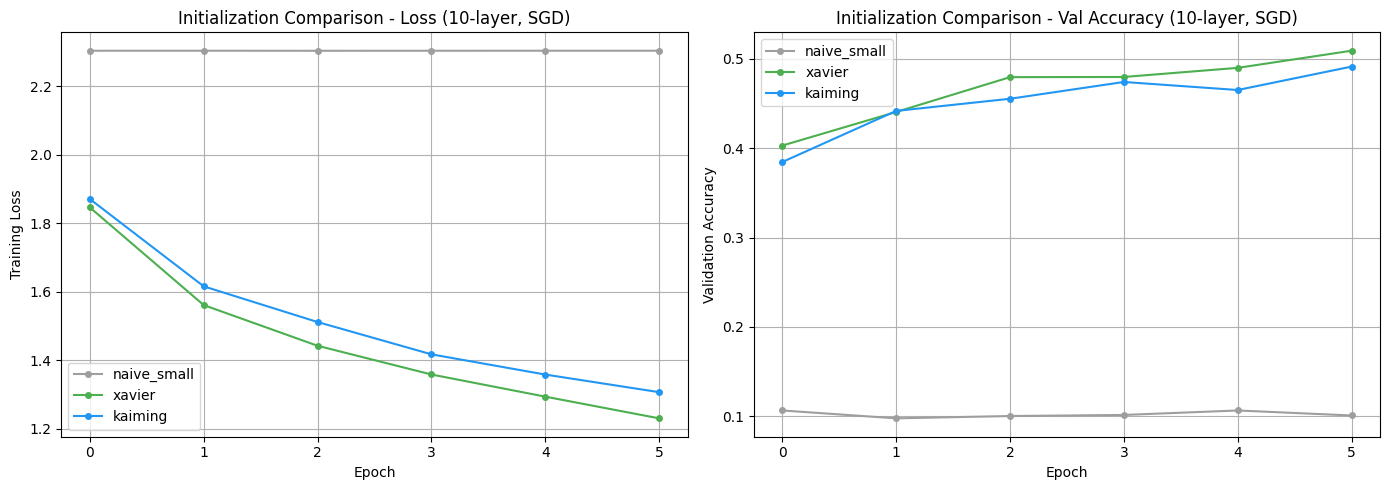

naive_small: Best val acc = 0.1064
xavier: Best val acc = 0.5092
kaiming: Best val acc = 0.4914


In [8]:
# 초기화 방법별 비교 (10-layer network, SGD)
init_methods = ['naive_small', 'xavier', 'kaiming']
init_results = {}

for method in init_methods:
    print(f'\n=== Init: {method} ===')
    torch.manual_seed(42)
    model = build_mlp([256] * 9)   # 10-layer
    init_weights(model, method)
    optimizer = optim.SGD(model.parameters(), lr=0.05, momentum=0.9)
    history = train_model(model, optimizer, train_loader, val_loader, epochs=6)
    init_results[method] = history

# Loss/Accuracy 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#9E9E9E', '#4CAF50', '#2196F3']

for (name, hist), color in zip(init_results.items(), colors):
    axes[0].plot(hist['train_loss'], '-o', label=name, color=color, markersize=4)
    axes[1].plot(hist['val_acc'], '-o', label=name, color=color, markersize=4)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Loss')
axes[0].set_title('Initialization Comparison - Loss (10-layer, SGD)')
axes[0].legend()
axes[0].grid(True)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Initialization Comparison - Val Accuracy (10-layer, SGD)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

for name, hist in init_results.items():
    print(f'{name}: Best val acc = {max(hist["val_acc"]):.4f}')


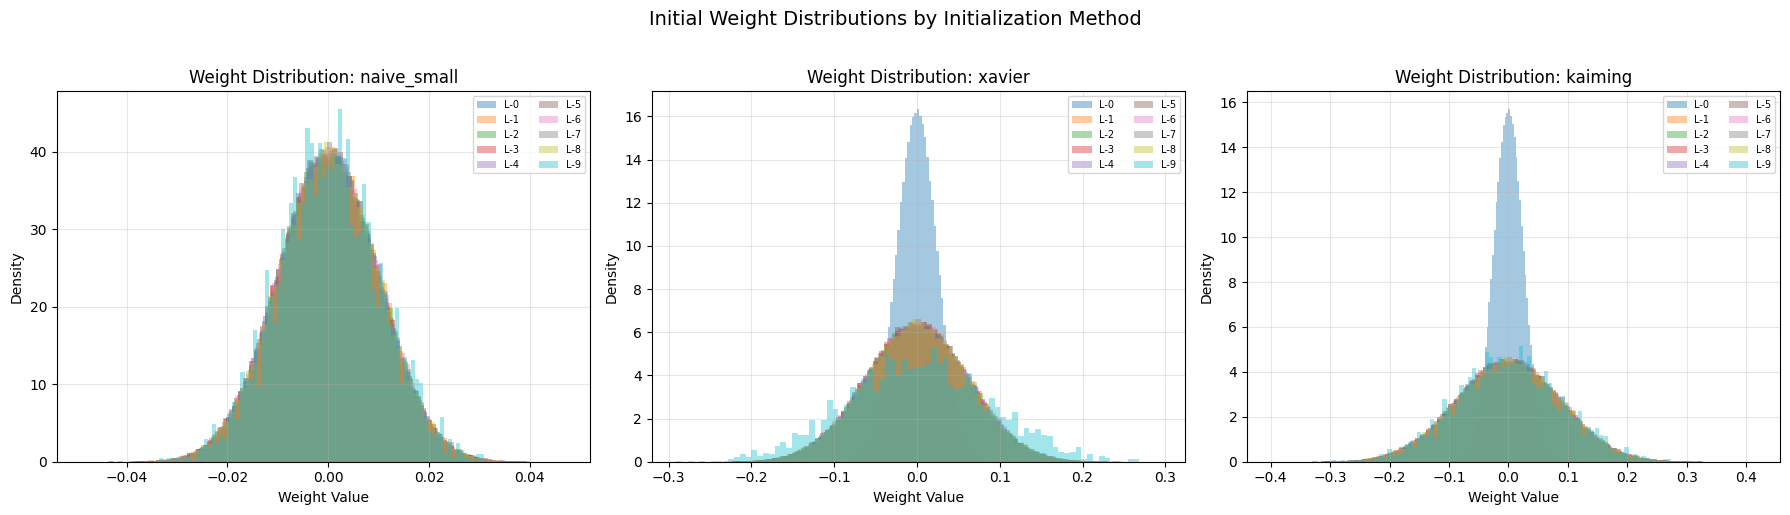

Observation: naive_small uses a fixed std=0.01 — weights are tightly clustered near 0.
Xavier and Kaiming choose the variance based on layer fan-in / fan-out so the scale
is closer to a "useful" range for forward and backward signal flow.


In [9]:
# Weight Distribution 시각화: 각 초기화 방법별 가중치 히스토그램 비교
# (학습 전 상태에서의 초기 가중치 분포)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, method in enumerate(init_methods):
    ax = axes[idx]
    torch.manual_seed(42)
    model = build_mlp([256] * 9)
    init_weights(model, method)

    layer_idx = 0
    for module in model.modules():
        if isinstance(module, nn.Linear):
            weights = module.weight.data.cpu().numpy().flatten()
            ax.hist(weights, bins=80, alpha=0.4, density=True,
                    label=f'L-{layer_idx}')
            layer_idx += 1

    ax.set_title(f'Weight Distribution: {method}')
    ax.set_xlabel('Weight Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)

plt.suptitle('Initial Weight Distributions by Initialization Method', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('Observation: naive_small uses a fixed std=0.01 — weights are tightly clustered near 0.')
print('Xavier and Kaiming choose the variance based on layer fan-in / fan-out so the scale')
print('is closer to a "useful" range for forward and backward signal flow.')


## 3. Batch Normalization

### 배경: Internal Covariate Shift

네트워크의 각 레이어는 이전 레이어의 출력을 입력으로 받습니다.
학습 중 앞쪽 레이어의 가중치가 업데이트되면서, 뒤쪽 레이어가 받는 **입력 분포가 계속 변하는 현상**이 관찰됩니다. 이를 **Internal Covariate Shift (ICS)** 라고 부릅니다.

```
학습 초반:    Layer 1 출력 ~ N(0.5, 1.0)
학습 중간:    Layer 1 출력 ~ N(-0.2, 2.3)   (분포가 이동)
학습 후반:    Layer 1 출력 ~ N(0.1, 0.8)    (또 이동)
```

Batch Normalization은 원래 논문(Ioffe & Szegedy, 2015)에서 ICS를 줄이기 위한 기법으로 제안되었습니다.
다만 후속 연구(Santurkar et al., 2018 *"How Does Batch Normalization Help Optimization?"*)에서는
BN의 효과를 ICS 감소보다 **loss landscape의 smoothing**으로 설명하는 등, 정확한 작동 원리에 대해서는 여러 해석이 존재합니다.
이 실습에서는 BN이 학습 양상에 어떤 변화를 가져오는지 **실험으로 관찰**하는 데 초점을 둡니다.

### Batch Normalization의 수식

각 hidden layer의 출력 $h$에 대해 미니배치 단위로 정규화합니다:

$$\hat{h} = \frac{h - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}, \quad y = \gamma \hat{h} + \beta$$

- $\mu_B, \sigma_B^2$: 미니배치의 평균과 분산
- $\gamma, \beta$: 학습 가능한 파라미터 (scale, shift) — 정규화 후에도 표현력을 유지
- $\epsilon$: 분모가 0이 되는 것을 방지하는 작은 상수

### PyTorch 사용법
```python
nn.BatchNorm1d(num_features)  # FC layer 뒤에 사용
nn.BatchNorm2d(num_features)  # Conv layer 뒤에 사용 (Day 3에서)
```

> **참고**: BN 레이어는 `model.train()`과 `model.eval()`에서 동작이 달라집니다.
> - Train: 미니배치 통계 사용 + running mean/var 업데이트
> - Eval: 누적된 running mean/var 사용 (추론 시 일관성 확보)

In [10]:
def build_mlp_with_bn(hidden_dims, input_dim=3*32*32, num_classes=10):
    """
    Batch Normalization이 포함된 MLP를 만드세요.

    구조: Flatten -> [Linear -> BN -> ReLU] x len(hidden_dims) -> Linear

    Args:
        hidden_dims: hidden layer 크기 리스트
        input_dim: 입력 차원
        num_classes: 출력 클래스 수
    Returns:
        nn.Sequential 모델
    Hint: build_mlp와 비슷하지만, 각 Linear 뒤에 nn.BatchNorm1d(h)를 추가하세요.
          순서는 Linear -> BatchNorm -> ReLU 입니다.
          마지막 출력 Linear 뒤에는 BN을 넣지 않습니다.
    """
    ############################################################################
    # TODO 3: build_mlp_with_bn을 구현하세요 (~10줄)                             #
    ############################################################################
    layers = [nn.Flatten()]
    in_dim = input_dim
    for h in hidden_dims:
        layers.append(nn.Linear(in_dim, h))
        layers.append(nn.BatchNorm1d(h))
        layers.append(nn.ReLU())
        in_dim = h
    layers.append(nn.Linear(in_dim, num_classes))
    return nn.Sequential(*layers)
    #                             END OF YOUR CODE                             #
    ############################################################################

# 테스트
test_bn_model = build_mlp_with_bn([256, 256])
print(test_bn_model)
print(f'Total parameters: {sum(p.numel() for p in test_bn_model.parameters()):,}')

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=3072, out_features=256, bias=True)
  (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): ReLU()
  (4): Linear(in_features=256, out_features=256, bias=True)
  (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU()
  (7): Linear(in_features=256, out_features=10, bias=True)
)
Total parameters: 856,074


=== 20-layer WITHOUT BatchNorm (Kaiming, SGD lr=0.1) ===
Epoch 1/6 | Loss: 2.3565 | Train Acc: 0.1473 | Val Acc: 0.1414
Epoch 2/6 | Loss: 2.2460 | Train Acc: 0.1838 | Val Acc: 0.1868
Epoch 3/6 | Loss: 2.0896 | Train Acc: 0.1747 | Val Acc: 0.1740
Epoch 4/6 | Loss: 2.0139 | Train Acc: 0.2285 | Val Acc: 0.2258
Epoch 5/6 | Loss: 1.9866 | Train Acc: 0.2288 | Val Acc: 0.2222
Epoch 6/6 | Loss: 1.9535 | Train Acc: 0.2542 | Val Acc: 0.2446

=== 20-layer WITH BatchNorm (Kaiming, SGD lr=0.1) ===
Epoch 1/6 | Loss: 2.0883 | Train Acc: 0.3044 | Val Acc: 0.2996
Epoch 2/6 | Loss: 1.9147 | Train Acc: 0.3442 | Val Acc: 0.3356
Epoch 3/6 | Loss: 1.7892 | Train Acc: 0.3667 | Val Acc: 0.3540
Epoch 4/6 | Loss: 1.7401 | Train Acc: 0.3804 | Val Acc: 0.3724
Epoch 5/6 | Loss: 1.6852 | Train Acc: 0.4126 | Val Acc: 0.3942
Epoch 6/6 | Loss: 1.6389 | Train Acc: 0.4321 | Val Acc: 0.4072


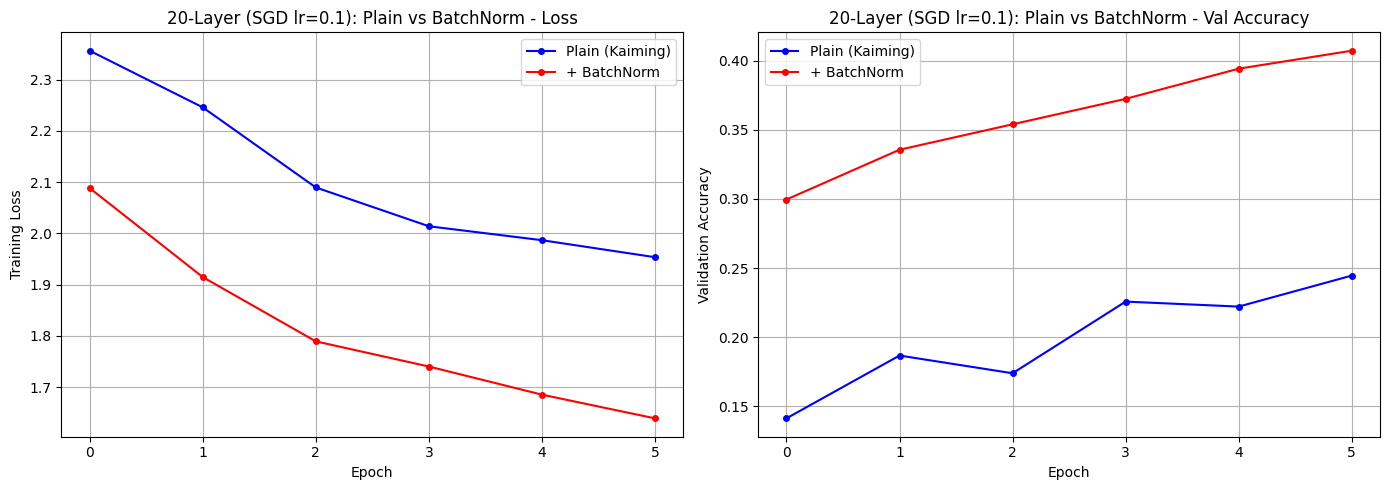

Plain (Kaiming) best val acc: 0.2446
+ BatchNorm best val acc:     0.4072


In [11]:
# Batch Normalization 효과 비교 (20-layer, SGD lr=0.1)
# 깊은 네트워크를 빠른 lr로 돌리면 plain은 보통 학습이 잘 안 되거나 발산하고,
# BN을 추가하면 같은 lr에서도 안정적으로 학습되는 경향이 관찰됩니다.
print('=== 20-layer WITHOUT BatchNorm (Kaiming, SGD lr=0.1) ===')
torch.manual_seed(42)
model_plain = build_mlp([256] * 19)
init_weights(model_plain, 'kaiming')
opt_plain = optim.SGD(model_plain.parameters(), lr=0.1, momentum=0.9)
hist_plain = train_model(model_plain, opt_plain, train_loader, val_loader, epochs=6)

print('\n=== 20-layer WITH BatchNorm (Kaiming, SGD lr=0.1) ===')
torch.manual_seed(42)
model_bn = build_mlp_with_bn([256] * 19)
init_weights(model_bn, 'kaiming')
opt_bn = optim.SGD(model_bn.parameters(), lr=0.1, momentum=0.9)
hist_bn = train_model(model_bn, opt_bn, train_loader, val_loader, epochs=6)

# 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hist_plain['train_loss'], 'b-o', label='Plain (Kaiming)', markersize=4)
axes[0].plot(hist_bn['train_loss'], 'r-o', label='+ BatchNorm', markersize=4)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Loss')
axes[0].set_title('20-Layer (SGD lr=0.1): Plain vs BatchNorm - Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(hist_plain['val_acc'], 'b-o', label='Plain (Kaiming)', markersize=4)
axes[1].plot(hist_bn['val_acc'], 'r-o', label='+ BatchNorm', markersize=4)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('20-Layer (SGD lr=0.1): Plain vs BatchNorm - Val Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f'Plain (Kaiming) best val acc: {max(hist_plain["val_acc"]):.4f}')
print(f'+ BatchNorm best val acc:     {max(hist_bn["val_acc"]):.4f}')


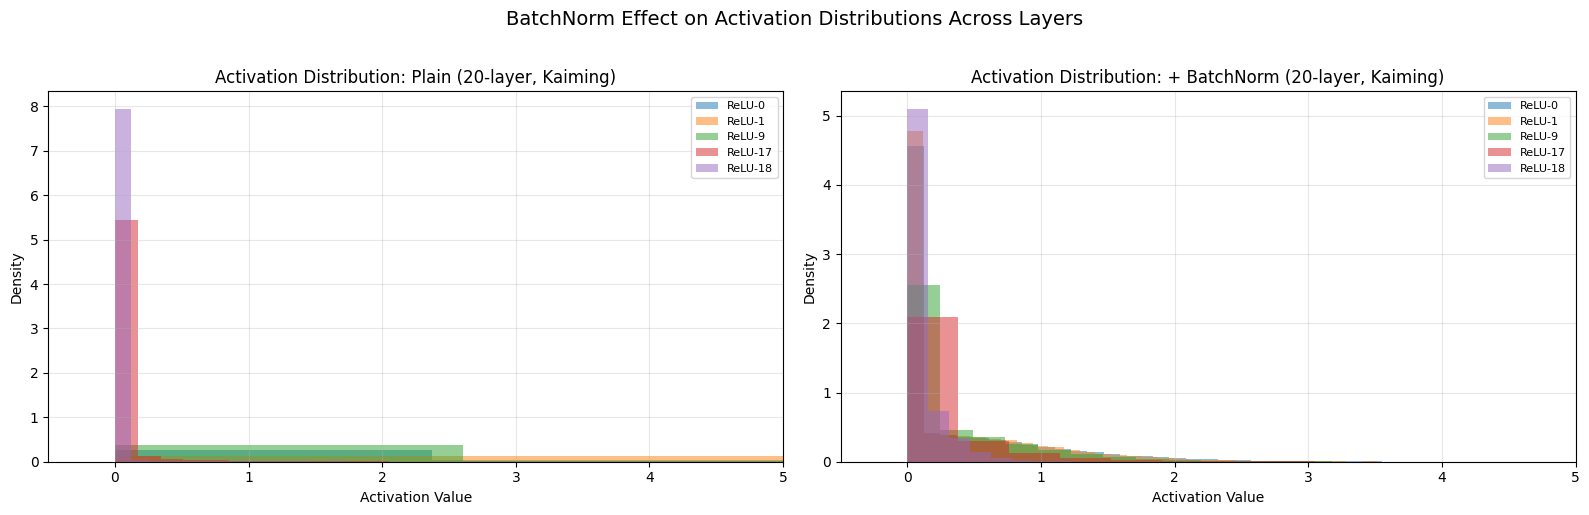

Observation (this run): with BatchNorm, the activation distributions across layers
look more consistent. Without BN, deeper layers in the plain stack tend to drift /
collapse as the high-lr SGD pushes things around.


In [12]:
# Activation Distribution 비교: Plain vs BatchNorm  (20-layer)
# BN이 어떻게 activation 분포를 정규화하는지 시각적으로 확인합니다.
# 20-layer는 ReLU 출력이 너무 많아 첫 / 가운데 / 마지막 몇 개만 골라서 표시합니다.

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

acts_plain = collect_activations(model_plain, val_loader, max_batches=2)
ax = axes[0]
plotted_any = False
for layer_name, values in subsample_layers(acts_plain):
    finite = values[np.isfinite(values)]
    if len(finite) > 0:
        ax.hist(finite, bins=50, alpha=0.5, density=True, label=layer_name)
        plotted_any = True
if not plotted_any:
    ax.text(0.5, 0.5, 'plain diverged (NaN activations)\n--- nothing to show ---',
            ha='center', va='center', transform=ax.transAxes,
            fontsize=12, color='#D32F2F')
ax.set_title('Activation Distribution: Plain (20-layer, Kaiming)')
ax.set_xlabel('Activation Value')
ax.set_ylabel('Density')
ax.set_xlim(-0.5, 5)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

acts_bn = collect_activations(model_bn, val_loader, max_batches=2)
ax = axes[1]
for layer_name, values in subsample_layers(acts_bn):
    ax.hist(values, bins=50, alpha=0.5, density=True, label=layer_name)
ax.set_title('Activation Distribution: + BatchNorm (20-layer, Kaiming)')
ax.set_xlabel('Activation Value')
ax.set_ylabel('Density')
ax.set_xlim(-0.5, 5)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle('BatchNorm Effect on Activation Distributions Across Layers', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('Observation (this run): with BatchNorm, the activation distributions across layers')
print('look more consistent. Without BN, deeper layers in the plain stack tend to drift /')
print('collapse as the high-lr SGD pushes things around.')


## 4. Summary Comparison

지금까지의 모든 실험 결과를 한눈에 비교합니다.

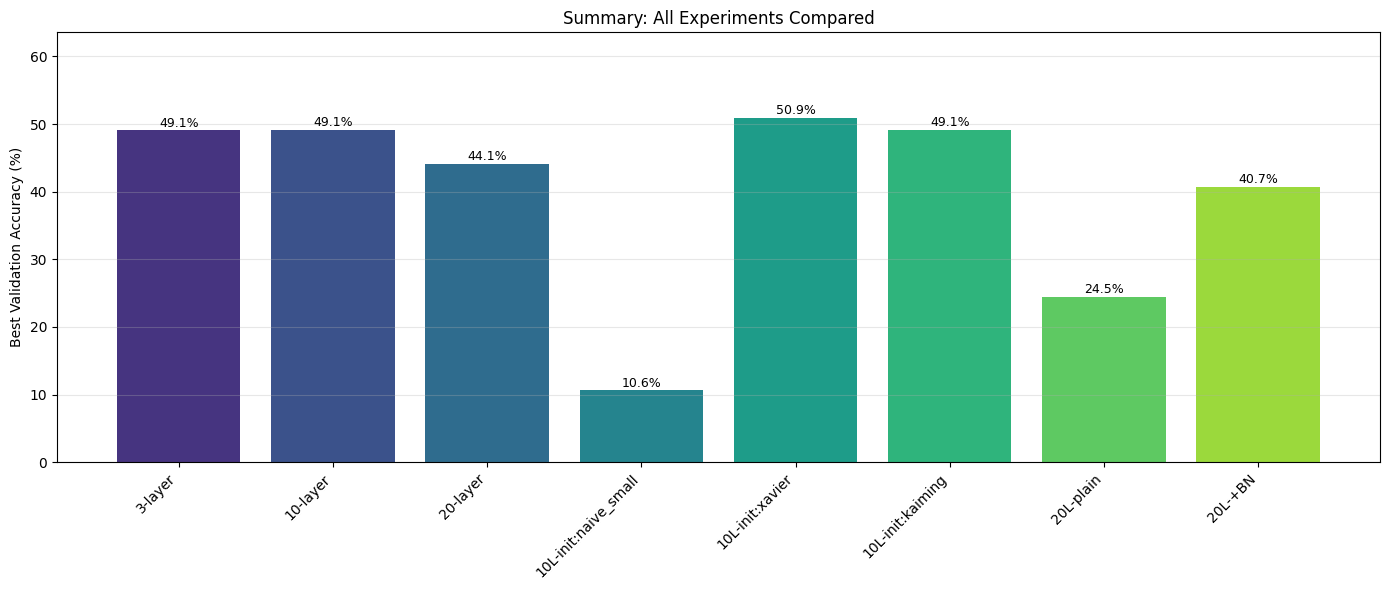

Observations (this experiment):
1. With SGD, going from 10 to 20 layers hurt val accuracy in the plain case.
2. naive_small init failed to train at all on a 10-layer network (gradients too tiny).
3. At 20 layers with the high-lr SGD setup, BatchNorm stabilized training where the
   plain stack struggled (often diverging or staying near random).


In [13]:
# 종합 비교: 모든 실험의 best validation accuracy
summary = {}

for name, hist in depth_results.items():
    summary[name] = max(hist['val_acc'])

for name, hist in init_results.items():
    summary[f'10L-init:{name}'] = max(hist['val_acc'])

summary['20L-plain'] = max(hist_plain['val_acc'])
summary['20L-+BN'] = max(hist_bn['val_acc'])

fig, ax = plt.subplots(figsize=(14, 6))
names = list(summary.keys())
accs = [v * 100 for v in summary.values()]
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(names)))
bars = ax.bar(names, accs, color=colors)

ax.set_ylabel('Best Validation Accuracy (%)')
ax.set_title('Summary: All Experiments Compared')
ax.set_ylim(0, max(accs) * 1.15 + 5)
plt.xticks(rotation=45, ha='right')
ax.grid(True, axis='y', alpha=0.3)

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{acc:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print('Observations (this experiment):')
print('1. With SGD, going from 10 to 20 layers hurt val accuracy in the plain case.')
print('2. naive_small init failed to train at all on a 10-layer network (gradients too tiny).')
print('3. At 20 layers with the high-lr SGD setup, BatchNorm stabilized training where the')
print('   plain stack struggled (often diverging or staying near random).')


## 5. Best Model Challenge

지금까지 살펴본 기법들을 조합해 CIFAR-10에서 val accuracy를 높여봅니다.
정답은 없으며, 각 항목을 켜고 끄면서 결과가 어떻게 달라지는지 관찰해보는 것을 목표로 합니다.

### Checklist (시도해볼 수 있는 옵션)

- [ ] **Hidden layer 크기**: 256, 512, 1024 등 다양하게 시도
- [ ] **깊이**: 3~7 레이어 (깊게 갈수록 학습 난이도가 오르는 경향)
- [ ] **Batch Normalization**: 각 hidden layer 뒤에 추가
- [ ] **Kaiming Initialization**: ReLU 기반 네트워크에서 권장
- [ ] **Dropout**: `nn.Dropout(p=0.3~0.5)` — overfitting 완화 목적
- [ ] **Weight Decay**: `optimizer(... weight_decay=1e-4)` — L2 regularization
- [ ] **Learning Rate**: Adam은 1e-3이 기본, 더 작게/크게 시도
- [ ] **Optimizer**: Adam vs SGD+Momentum (momentum=0.9)
- [ ] **Epochs**: 15~20 정도 (너무 많으면 overfitting 가능)

> **참고 수치**: 이 환경에서 FC network만으로는 val accuracy가 대체로 50% 안팎에 머무르는 경향이 있습니다.
> 이미지의 **공간 구조(spatial structure)**를 활용하는 Convolutional Neural Network는 Day 3에서 다룹니다.

In [14]:
############################################################################
# TODO 4 (Bonus): 최적의 FC 모델을 설계하고 학습하세요                           #
# 위의 checklist를 참고하여 자유롭게 설계하세요!                                  #
# 아래는 예시입니다 — 마음대로 수정하세요.                                        #
############################################################################
torch.manual_seed(42)

# 예시: BN + Dropout + Kaiming + Weight Decay
best_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(3*32*32, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Linear(128, 10),
)
init_weights(best_model, 'kaiming')

best_optimizer = optim.Adam(best_model.parameters(), lr=1e-3, weight_decay=1e-4)
print('Training best model...')
best_history = train_model(best_model, best_optimizer, train_loader, val_loader, epochs=15)
#                             END OF YOUR CODE                             #
############################################################################

Training best model...
Epoch 1/15 | Loss: 1.7995 | Train Acc: 0.4629 | Val Acc: 0.4438
Epoch 2/15 | Loss: 1.5725 | Train Acc: 0.5031 | Val Acc: 0.4742
Epoch 3/15 | Loss: 1.4883 | Train Acc: 0.5399 | Val Acc: 0.5054
Epoch 4/15 | Loss: 1.4176 | Train Acc: 0.5501 | Val Acc: 0.5060
Epoch 5/15 | Loss: 1.3775 | Train Acc: 0.5724 | Val Acc: 0.5168
Epoch 6/15 | Loss: 1.3387 | Train Acc: 0.5840 | Val Acc: 0.5294
Epoch 7/15 | Loss: 1.3026 | Train Acc: 0.5993 | Val Acc: 0.5346
Epoch 8/15 | Loss: 1.2774 | Train Acc: 0.6126 | Val Acc: 0.5324
Epoch 9/15 | Loss: 1.2536 | Train Acc: 0.6250 | Val Acc: 0.5448
Epoch 10/15 | Loss: 1.2288 | Train Acc: 0.6335 | Val Acc: 0.5440
Epoch 11/15 | Loss: 1.2050 | Train Acc: 0.6466 | Val Acc: 0.5586
Epoch 12/15 | Loss: 1.1827 | Train Acc: 0.6551 | Val Acc: 0.5568
Epoch 13/15 | Loss: 1.1637 | Train Acc: 0.6660 | Val Acc: 0.5534
Epoch 14/15 | Loss: 1.1471 | Train Acc: 0.6772 | Val Acc: 0.5622
Epoch 15/15 | Loss: 1.1272 | Train Acc: 0.6789 | Val Acc: 0.5686


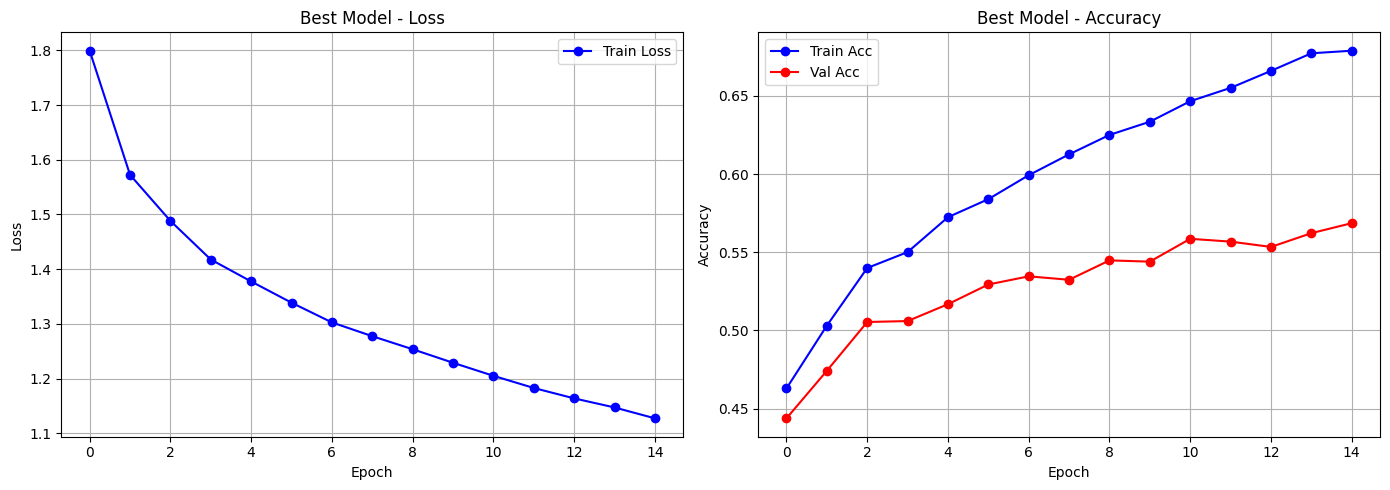

Best validation accuracy: 0.5686
Test accuracy:            0.5601
Target reached! Great job combining the techniques.


In [15]:
# Best model 결과 시각화
plot_history(best_history, 'Best Model')

# Test set 최종 평가
best_model.to(device)
test_acc = check_accuracy(test_loader, best_model)
val_acc = max(best_history['val_acc'])
print(f'Best validation accuracy: {val_acc:.4f}')
print(f'Test accuracy:            {test_acc:.4f}')

if val_acc >= 0.52:
    print('Target reached! Great job combining the techniques.')
else:
    print(f'Target: 0.5200 | Gap: {0.52 - val_acc:.4f} -- try adjusting hyperparameters!')

## Summary

이번 실습에서 관찰한 현상과 대응 기법:

| 관찰된 현상 | 다룬 기법 | 실험에서 나타난 경향 |
|-----------|----------|---------------------|
| 깊이 증가 시 학습이 어려워지는 경향 | **Kaiming 초기화** | 얕은 레이어 gradient norm이 유지되는 경향이 관찰됨 |
| 레이어 입력 분포 변화 (ICS) | **Batch Normalization** | 레이어 간 activation 분포가 더 일관되는 경향이 관찰됨 |
| Train/Val 격차 (overfitting) | **Dropout + Weight Decay** | Val accuracy의 악화가 완화되는 경향 |

### 실용 Tips

**1. `model.apply(init_fn)` 패턴**
```python
def kaiming_init(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        nn.init.zeros_(m.bias)
model.apply(kaiming_init)  # 모든 하위 모듈에 적용
```

**2. `torchsummary`로 모델 구조 확인**
```python
# !pip install torchsummary
from torchsummary import summary
summary(model, input_size=(3, 32, 32))  # 각 레이어별 출력 shape과 파라미터 수 확인
```

**3. Gradient Clipping**
```python
# gradient가 너무 커지는 것을 방지 (특히 RNN에서 유용)
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
```

**4. Experiment Tracking with W&B**
```python
# !pip install wandb
import wandb
wandb.init(project='cifar10-mlp')
wandb.log({'train_loss': loss, 'val_acc': val_acc})
# 실험 결과를 자동으로 기록하고 대시보드에서 비교 가능
```

### Day 2 전체 요약

| 실습 | 핵심 내용 |
|-----|----------|
| **260413-1** | NumPy로 backpropagation 직접 구현 → 원리 이해 |
| **260413-2** | PyTorch nn.Module/Sequential로 실전 MLP 구현 |
| **260413-3** | 깊은 네트워크의 문제(vanishing gradient)와 해결(초기화, BN, Dropout) |

> FC만 사용하는 환경에서는 val accuracy가 50% 부근에서 더 이상 크게 오르지 않는 경향이 관찰됩니다.
> 이미지의 **공간 구조(spatial structure)**를 활용하는 Convolutional Neural Network는 Day 3에서 살펴봅니다.